# Kangaroo Rat and Pocket Mouse Observations in Arizona

This notebook uses the iNaturalist API to retrieve observations of kangaroo rats and pocket mice in Arizona. The analysis compares monthly observation totals and the species represented in the returned 2025 sample.

The results describe iNaturalist reporting activity, not population abundance. Observation counts can also reflect weather, animal activity, accessibility, and the amount of time people spend making observations.

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

## API setup

The iNaturalist API uses taxon IDs to filter observations. The IDs below represent the *Dipodomys* genus (kangaroo rats) and the pocket-mouse subfamily. Arizona is represented by iNaturalist place ID `40`.

In [2]:
API_URL = "https://api.inaturalist.org/v1/observations"
ARIZONA_PLACE_ID = 40
YEAR = 2025

TAXA = {
    "Kangaroo rats": 44098,   # Dipodomys
    "Pocket mice": 481657     # Perognathinae
}

def get_observations(params):
    """Request observations and raise a clear error for unsuccessful calls."""
    response = requests.get(API_URL, params=params, timeout=30)
    response.raise_for_status()
    return response.json()

print("API ready for", ", ".join(TAXA))

API ready for Kangaroo rats, Pocket mice


In [3]:
test_data = get_observations({
    "taxon_id": TAXA["Kangaroo rats"],
    "place_id": ARIZONA_PLACE_ID,
    "year": YEAR,
    "per_page": 1
})

print("Status: request succeeded")
print("Available response keys:", list(test_data.keys()))
print("Kangaroo rat observations in the selected year:", test_data["total_results"])

Status: request succeeded
Available response keys: ['total_results', 'page', 'per_page', 'results']
Kangaroo rat observations in the selected year: 76


In [4]:
months = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
monthly_rows = []

for group_name, taxon_id in TAXA.items():
    for month_number, month_name in enumerate(months, start=1):
        data = get_observations({
            "taxon_id": taxon_id,
            "place_id": ARIZONA_PLACE_ID,
            "year": YEAR,
            "month": month_number,
            "per_page": 1
        })
        monthly_rows.append({
            "Group": group_name,
            "Month": month_name,
            "Month number": month_number,
            "Observations": data["total_results"]
        })

monthly_data = pd.DataFrame(monthly_rows)
monthly_data.head()

,Group,Month,Month number,Observations
0,Kangaroo rats,January,1,1
1,Kangaroo rats,February,2,1
2,Kangaroo rats,March,3,8
3,Kangaroo rats,April,4,4
4,Kangaroo rats,May,5,6


In [5]:
monthly_pivot = monthly_data.pivot(
    index="Month",
    columns="Group",
    values="Observations"
).reindex(months)

print(monthly_pivot)

Group      Kangaroo rats  Pocket mice
Month                                
January                1            1
February               1            1
March                  8            5
April                  4           14
May                    6           13
June                   7           22
July                   9           21
August                13           27
September             12           23
October                9           10
November               4            8
December               2            8


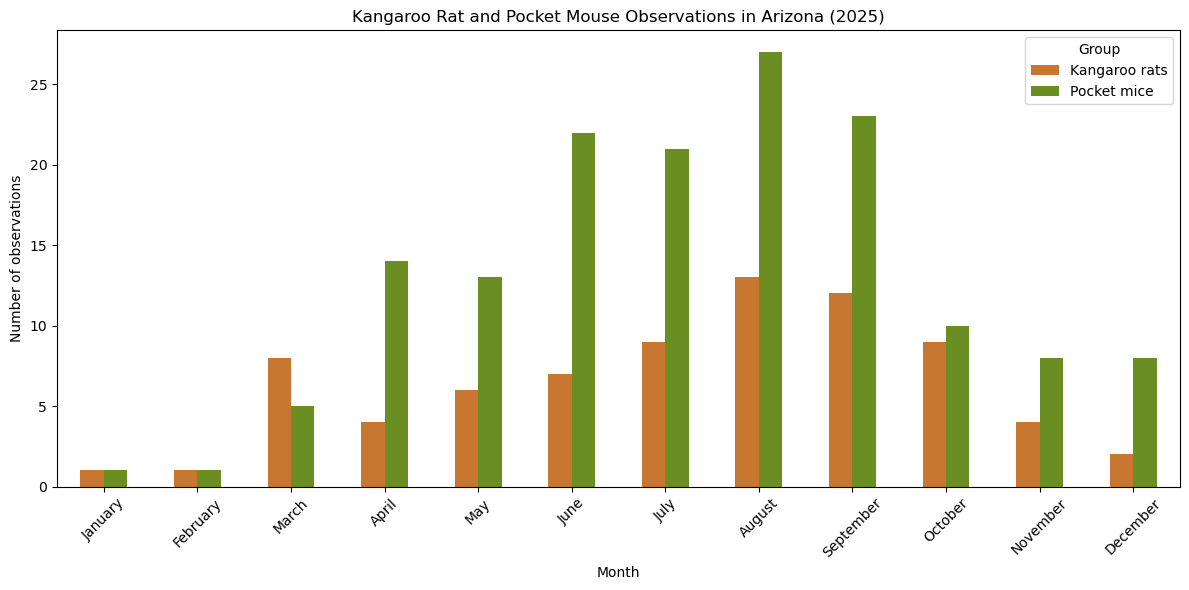

In [6]:
ax = monthly_pivot.plot(
    kind="bar",
    figsize=(12, 6),
    color=["#C7772F", "#6B8E23"]
)

ax.set_title(f"Kangaroo Rat and Pocket Mouse Observations in Arizona ({YEAR})")
ax.set_xlabel("Month")
ax.set_ylabel("Number of observations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Species-level observations

The next cells retrieve up to 200 observations for each group in Arizona during 2025. Only observations identified to species are included in the species comparison.

In [7]:
observation_rows = []
for group_name, taxon_id in TAXA.items():
    data = get_observations({
        "taxon_id": taxon_id,
        "place_id": ARIZONA_PLACE_ID,
        "year": YEAR,
        "per_page": 200,
        "order": "desc",
        "order_by": "observed_on"
    })

    for observation in data["results"]:
        taxon = observation.get("taxon") or {}
        if taxon.get("rank") == "species":
            observation_rows.append({
                "Group": group_name,
                "Scientific name": taxon.get("name"),
                "Common name": taxon.get("preferred_common_name") or "Unknown",
                "Observed on": observation.get("observed_on"),
                "Observation URL": observation.get("uri")
            })

species_data = pd.DataFrame(observation_rows)
print("Species-level observations retrieved:", len(species_data))
species_data.head()

Species-level observations retrieved: 166


,Group,Scientific name,Common name,Observed on,Observation URL
0,Kangaroo rats,Dipodomys spectabilis,Banner-tailed Kangaroo Rat,2025-11-29,https://www.inaturalist.org/observations/32884...
1,Kangaroo rats,Dipodomys merriami,Merriam's Kangaroo Rat,2025-11-27,https://www.inaturalist.org/observations/32870...
2,Kangaroo rats,Dipodomys merriami,Merriam's Kangaroo Rat,2025-11-12,https://www.inaturalist.org/observations/32629...
3,Kangaroo rats,Dipodomys merriami,Merriam's Kangaroo Rat,2025-10-19,https://www.inaturalist.org/observations/32185...
4,Kangaroo rats,Dipodomys spectabilis,Banner-tailed Kangaroo Rat,2025-10-17,https://www.inaturalist.org/observations/32141...


In [8]:
species_counts = (
    species_data.groupby(["Group", "Common name"])
    .size()
    .reset_index(name="Observations")
    .sort_values("Observations", ascending=False)
)

print(species_counts.head(10))

           Group                 Common name  Observations
5    Pocket mice         Desert Pocket Mouse            99
2  Kangaroo rats      Merriam's Kangaroo Rat            43
4    Pocket mice       Bailey's Pocket Mouse             8
3  Kangaroo rats          Ord's Kangaroo Rat             6
0  Kangaroo rats  Banner-tailed Kangaroo Rat             4
1  Kangaroo rats         Desert Kangaroo Rat             3
6    Pocket mice           Rock Pocket Mouse             2
7    Pocket mice          Silky Pocket Mouse             1


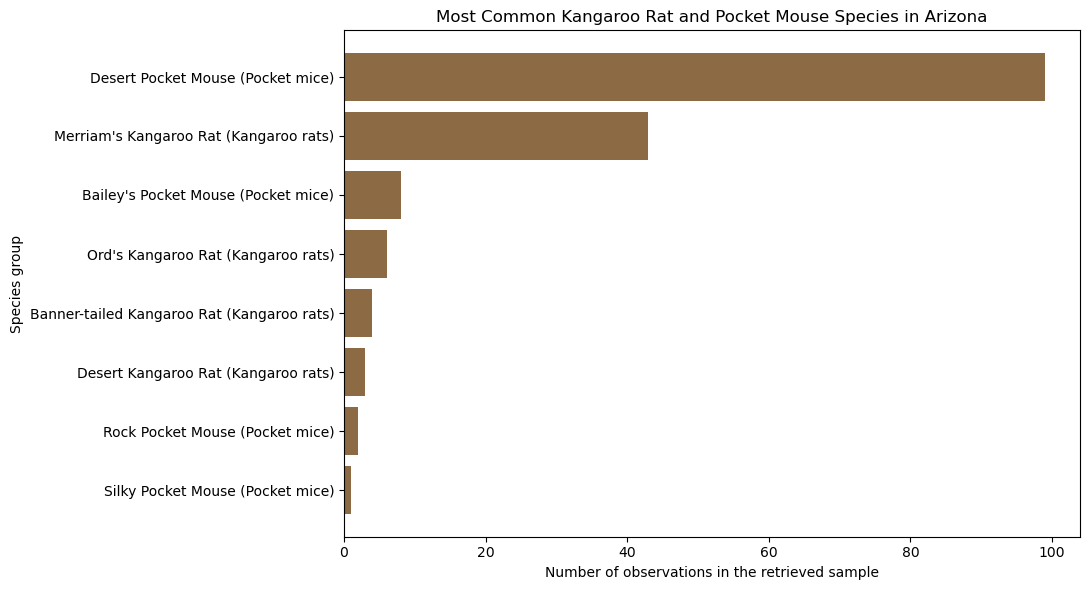

In [9]:
top_species = species_counts.head(10).sort_values("Observations")
labels = top_species["Common name"] + " (" + top_species["Group"] + ")"

plt.figure(figsize=(11, 6))
plt.barh(labels, top_species["Observations"], color="#8C6A43")
plt.title("Most Common Kangaroo Rat and Pocket Mouse Species in Arizona")
plt.xlabel("Number of observations in the retrieved sample")
plt.ylabel("Species group")
plt.tight_layout()
plt.show()